**Part 2: Computer Vision Problem Formulation and CNN Prototype**

**Task 1: Problem Identification**

**Selected Problem Type: Image Classification**

**Explanation:**
The dataset provided consists of images categorized into four distinct folders: 'normal', 'scratch', 'dent', and 'stain'. 

Image Classification is the most appropriate problem type because the goal is to assign a single categorical label to an entire image. In this manufacturing context, we are teaching the model to look at a product surface and classify it into one of the four predefined categories of defects (or lack thereof). 

We are not required to locate the defect within the image (Object Detection) or outline the defect's exact pixels (Segmentation); we simply need the model to recognize the visual patterns associated with each class and predict the correct label.

In [1]:
import os
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
import seaborn as sns
from PIL import Image
import tensorflow as tf
from tensorflow.keras import layers, models
from sklearn.model_selection import train_test_split
from sklearn.metrics import classification_report, confusion_matrix


**Task 2: Dataset Exploration**

--- Dataset Statistics ---
  Class Name  Image Count
0     normal          120
1    scratch          120
2       dent          120
3      stain          120

Total Classes: 4

[Output] Saved distribution chart to 'results/data_distribution.png'


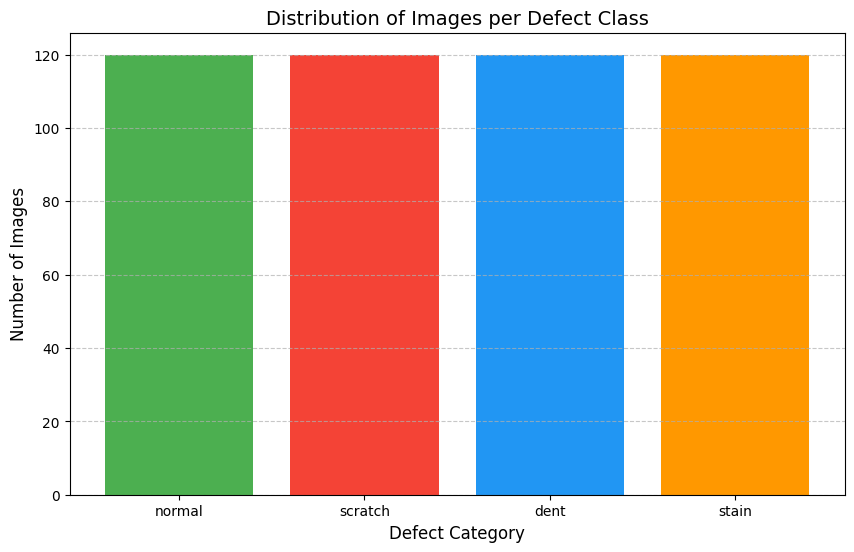

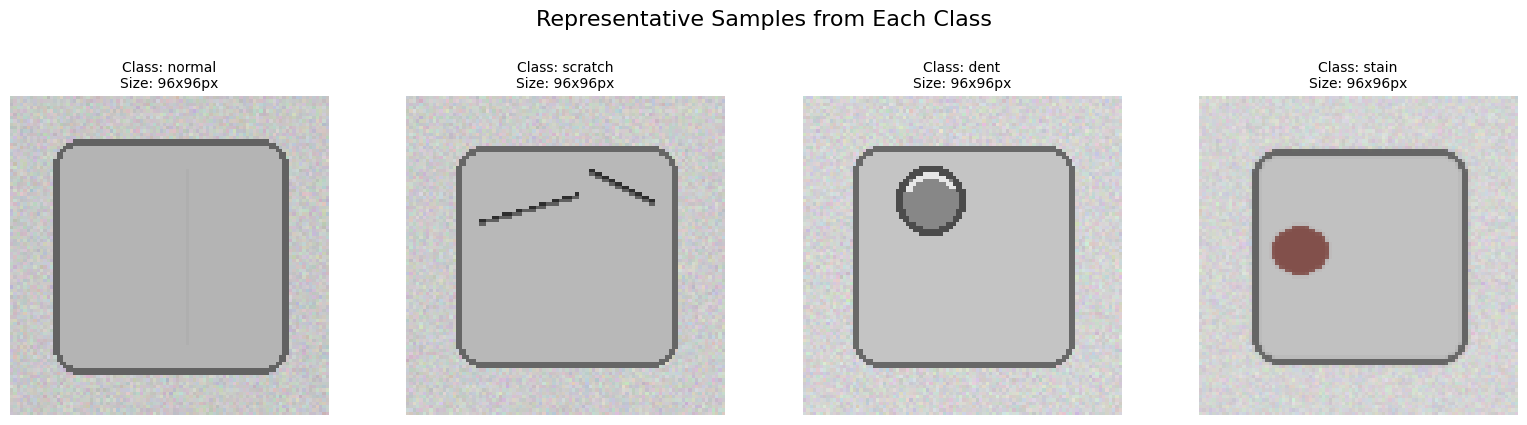

In [2]:
# CONFIGURATION
# Define the root directory and the target classes as per data_dictionary.md
data_dir = 'images'
classes = ['normal', 'scratch', 'dent', 'stain']


# DATASET ANALYSIS
# We iterate through folders to count files and verify data integrity
stats = []
for cls in classes:
    path = os.path.join(data_dir, cls)
    if os.path.exists(path):
        # Count only valid image files
        images = [f for f in os.listdir(path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))]
        stats.append({
            'Class Name': cls, 
            'Image Count': len(images),
            'Path': path
        })
    else:
        print(f"Warning: Folder for class '{cls}' not found at {path}")


# Display results in a structured table
df_stats = pd.DataFrame(stats)
print("--- Dataset Statistics ---")
print(df_stats[['Class Name', 'Image Count']])
print(f"\nTotal Classes: {len(classes)}")


# VISUALIZING DISTRIBUTION (Imbalance Check)
# A key requirement: Identify if the model will be biased toward a majority class
plt.figure(figsize=(10, 6))
colors = ['#4CAF50', '#F44336', '#2196F3', '#FF9800'] # Distinct colors for each class
plt.bar(df_stats['Class Name'], df_stats['Image Count'], color=colors)
plt.title('Distribution of Images per Defect Class', fontsize=14)
plt.xlabel('Defect Category', fontsize=12)
plt.ylabel('Number of Images', fontsize=12)
plt.grid(axis='y', linestyle='--', alpha=0.7)

# Ensure the results folder exists and save the chart
if not os.path.exists('results'):
    os.makedirs('results')
plt.savefig('results/data_distribution.png')
print("\n[Output] Saved distribution chart to 'results/data_distribution.png'")
plt.show()


# IMAGE DIMENSIONS & SAMPLE VISUALIZATION
# This step fulfills the "Sample images" and "Image dimensions" requirements
plt.figure(figsize=(16, 4))

for i, cls in enumerate(classes):
    class_path = os.path.join(data_dir, cls)
    # Get the first image file in the directory
    first_img_name = [f for f in os.listdir(class_path) if f.lower().endswith(('.png', '.jpg', '.jpeg'))][0]
    img_path = os.path.join(class_path, first_img_name)
    
    with Image.open(img_path) as img:
        width, height = img.size
        
        plt.subplot(1, 4, i+1)
        plt.imshow(img)
        # Displaying class name and dimensions (Width x Height) for the report
        plt.title(f"Class: {cls}\nSize: {width}x{height}px", fontsize=10)
        plt.axis('off')

plt.suptitle('Representative Samples from Each Class', fontsize=16, y=1.05)
plt.tight_layout()
plt.show()

**Task 3: Image Preprocessing**

In [3]:
# 1. Load the "Map" (the CSV file)
labels_df = pd.read_csv('labels.csv')

# 2. Settings
IMG_SIZE = 96 
images = []
labels = []

# This dictionary turns class names into numbers: 0, 1, 2, 3
# CNNs need numbers to do math
label_map = {'normal': 0, 'scratch': 1, 'dent': 2, 'stain': 3}

print("Starting Preprocessing using labels.csv")

# 3. Use the CSV to load each image
for index, row in labels_df.iterrows():
    img_path = row['filename']  # Get path from CSV
    class_name = row['class']   # Get defect type from CSV
    
    try:
        # Load, Resize, and Normalize
        img = Image.open(img_path).convert('RGB')
        img = img.resize((IMG_SIZE, IMG_SIZE))
        img_array = np.array(img) / 255.0  # Normalization (0 to 1)
        
        images.append(img_array)
        labels.append(label_map[class_name])
        
    except Exception as e:
        print(f"Error loading {img_path}: {e}")

# Convert lists to "Numpy Arrays" (the format CNNs require)
X = np.array(images)
y = np.array(labels)

# 4. Train-Test Split (80% training, 20% testing)
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.2, random_state=42)

print(f"\nSuccess!")
print(f"Images loaded via CSV: {len(X)}")
print(f"Ready for Training: {len(X_train)} samples")
print(f"Saved for Testing: {len(X_test)} samples")

Starting Preprocessing using labels.csv

Success!
Images loaded via CSV: 480
Ready for Training: 384 samples
Saved for Testing: 96 samples


**Task 4: CNN Model Creation**

In [4]:
model = models.Sequential([
    
    # 1. CONVOLUTION LAYER & ACTIVATION FUNCTION (ReLU)
    # This layer finds 32 different visual patterns
    layers.Conv2D(32, (3, 3), activation='relu', input_shape=(96, 96, 3)),
    
    # 2. POOLING LAYER
    # This layer reduces the size so the model is more efficient
    layers.MaxPooling2D((2, 2)),
    
    # Adding one more set of Conv/Pool to make the "Brain" stronger
    layers.Conv2D(64, (3, 3), activation='relu'),
    layers.MaxPooling2D((2, 2)),
    
    # 3. FLATTEN LAYER
    # Converts 2D image data into a 1D vector (a long list of numbers)
    layers.Flatten(),
    
    # 4. DENSE LAYER
    # The fully connected layer that learns the relationships between patterns
    layers.Dense(64, activation='relu'),
    
    # 5. OUTPUT LAYER
    # 4 neurons for our 4 classes: normal, scratch, dent, stain
    # 'softmax' ensures the 4 outputs add up to 100% probability
    layers.Dense(4, activation='softmax')
])

# COMPILING THE MODEL
# This "prepares" the model for training
model.compile(optimizer='adam',
              loss='sparse_categorical_crossentropy',
              metrics=['accuracy'])

# This prints the official "Map" of CNN
print("CNN Model successfully built!")
model.summary()

CNN Model successfully built!


C:\Users\Mitali Kalburgi\AppData\Roaming\Python\Python312\site-packages\keras\src\layers\convolutional\base_conv.py:113: UserWarning: Do not pass an `input_shape`/`input_dim` argument to a layer. When using Sequential models, prefer using an `Input(shape)` object as the first layer in the model instead.
  super().__init__(activity_regularizer=activity_regularizer, **kwargs)


Model: "sequential"

┏━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━━━━━━━━━━┳━━━━━━━━━━━━━━━┓
┃ Layer (type)                    ┃ Output Shape           ┃       Param # ┃
┡━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━━━━━━━━━━╇━━━━━━━━━━━━━━━┩
│ conv2d (Conv2D)                 │ (None, 94, 94, 32)     │           896 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d (MaxPooling2D)    │ (None, 47, 47, 32)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ conv2d_1 (Conv2D)               │ (None, 45, 45, 64)     │        18,496 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ max_pooling2d_1 (MaxPooling2D)  │ (None, 22, 22, 64)     │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ flatten (Flatten)               │ (None, 30976)          │             0 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense (Dense)                   │ (None, 64)             │     1,982,528 │
├─────────────────────────────────┼────────────────────────┼───────────────┤
│ dense_1 (Dense)                 │ (None, 4)              │           260 │
└─────────────────────────────────┴────────────────────────┴───────────────┘

 Total params: 2,002,180 (7.64 MB)

 Trainable params: 2,002,180 (7.64 MB)

 Non-trainable params: 0 (0.00 B)

**Task 5: Model Training and Evaluation**

In [ ]:
# Training the model
print("\nStarting Training...")

history = model.fit(
    X_train, y_train, 
    epochs=20, 
    validation_data=(X_test, y_test),
    batch_size=32,
    verbose=1
)



Starting Training...
Epoch 1/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 3s 104ms/step - accuracy: 0.2604 - loss: 1.8196 - val_accuracy: 0.2708 - val_loss: 1.3824
Epoch 2/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 79ms/step - accuracy: 0.2708 - loss: 1.3791 - val_accuracy: 0.3854 - val_loss: 1.3468
Epoch 3/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 77ms/step - accuracy: 0.3724 - loss: 1.3063 - val_accuracy: 0.2292 - val_loss: 1.3003
Epoch 4/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.5182 - loss: 1.1134 - val_accuracy: 0.5938 - val_loss: 0.9833
Epoch 5/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 82ms/step - accuracy: 0.7005 - loss: 0.8385 - val_accuracy: 0.7083 - val_loss: 0.8500
Epoch 6/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.7891 - loss: 0.6366 - val_accuracy: 0.8125 - val_loss: 0.6484
Epoch 7/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 81ms/step - accuracy: 0.8698 - loss: 0.4273 - val_accuracy: 0.8229 - val_loss: 0.5095
Epoch 8/20
12/12 ━━━━━━━━━━━━━━━━━━━━ 1s 76ms/step - accuracy: 0.9010 - loss: 0.3307 - v


Training complete!


Success! Training graphs and model file have been saved to the 'results' folder.


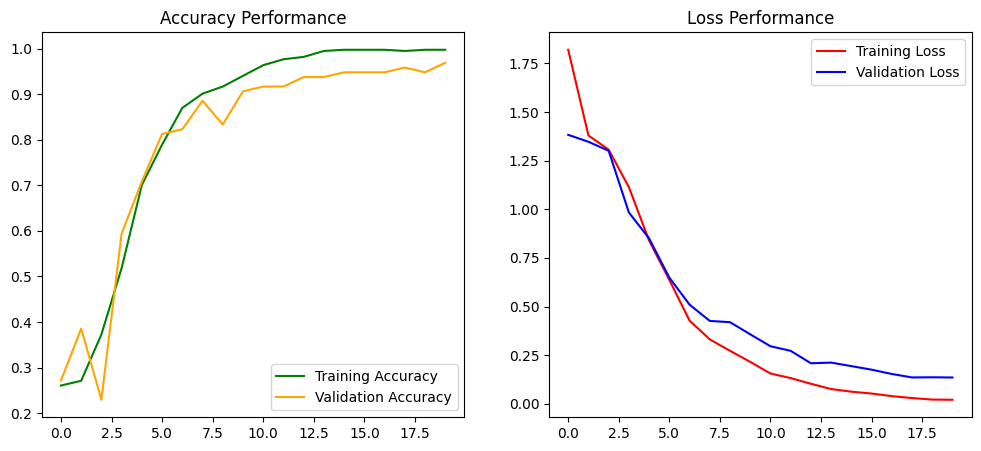

In [9]:
# Saving the training results

# 1. Save the Training Graphs (Using the 'history' from your previous cell)
plt.figure(figsize=(12, 5))

# Accuracy Plot
plt.subplot(1, 2, 1)
plt.plot(history.history['accuracy'], label='Training Accuracy', color='green')
plt.plot(history.history['val_accuracy'], label='Validation Accuracy', color='orange')
plt.title('Accuracy Performance')
plt.legend()

# Loss Plot
plt.subplot(1, 2, 2)
plt.plot(history.history['loss'], label='Training Loss', color='red')
plt.plot(history.history['val_loss'], label='Validation Loss', color='blue')
plt.title('Loss Performance')
plt.legend()

# Save the picture to the results folder
plt.savefig('results/accuracy_loss_curves.png')

# 2. Save the actual model file
model.save('results/cnn_model.keras')

print("Success! Training graphs and model file have been saved to the 'results' folder.")
plt.show()


Calculating final test scores...
Final Test Accuracy: 96.88%
3/3 ━━━━━━━━━━━━━━━━━━━━ 0s 26ms/step


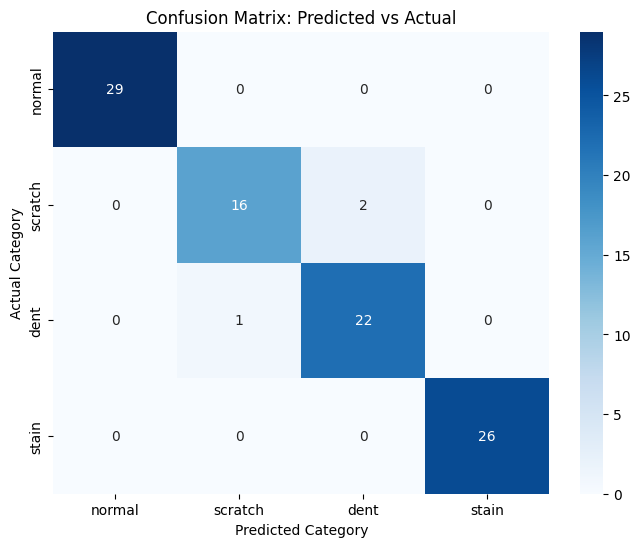

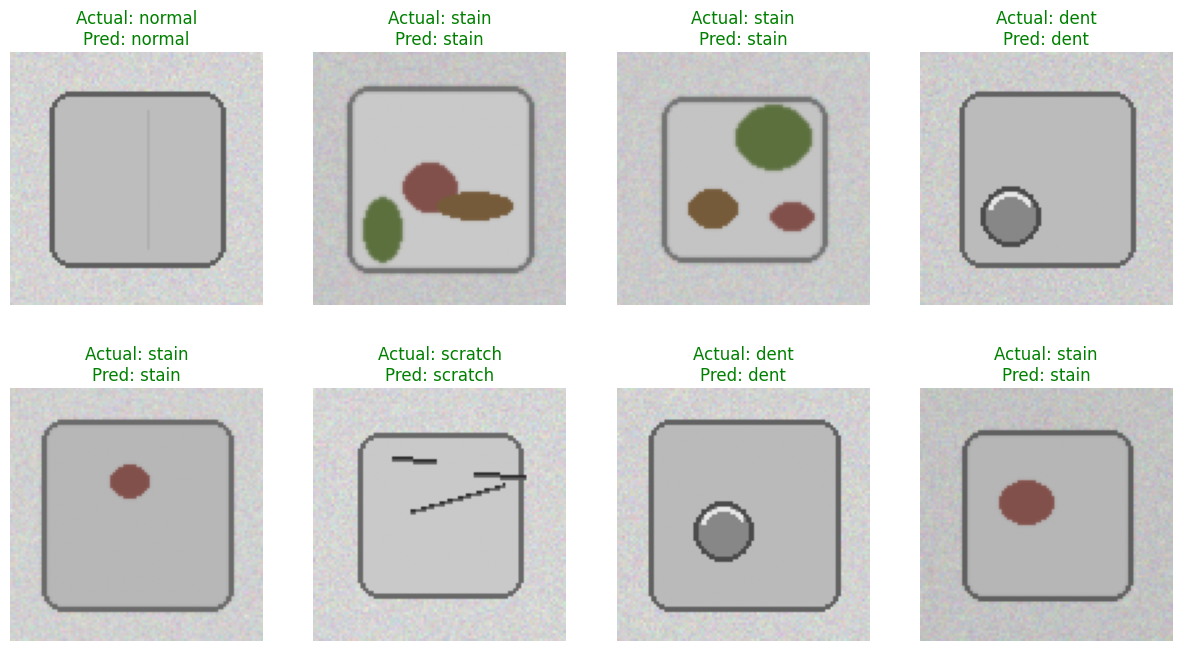

Evaluation complete! All outputs saved to results and sample_predictions folders.


In [8]:
# Evaluation

# 1. Evaluate the model on the Test Set (images it has never seen)
print("Calculating final test scores...")
test_loss, test_acc = model.evaluate(X_test, y_test, verbose=0)
print(f"Final Test Accuracy: {test_acc*100:.2f}%")

# 2. Generate the Confusion Matrix
y_pred = model.predict(X_test)
y_pred_classes = np.argmax(y_pred, axis=1)
cm = confusion_matrix(y_test, y_pred_classes)

plt.figure(figsize=(8, 6))
sns.heatmap(cm, annot=True, fmt='d', cmap='Blues', 
            xticklabels=classes, yticklabels=classes)
plt.title('Confusion Matrix: Predicted vs Actual')
plt.ylabel('Actual Category')
plt.xlabel('Predicted Category')

# Save to results folder
plt.savefig('results/confusion_matrix.png')
plt.show()

# 3. Create Sample Predictions
plt.figure(figsize=(15, 8))
for i in range(8):
    plt.subplot(2, 4, i+1)
    plt.imshow(X_test[i])
    
    actual_name = classes[y_test[i]]
    predicted_name = classes[y_pred_classes[i]]
    
    # Green if correct, Red if wrong
    color = 'green' if actual_name == predicted_name else 'red'
    plt.title(f"Actual: {actual_name}\nPred: {predicted_name}", color=color)
    plt.axis('off')

# Save to sample_predictions folder
if not os.path.exists('sample_predictions'):
    os.makedirs('sample_predictions')
plt.savefig('sample_predictions/prediction_outputs.png')
plt.show()

print("Evaluation complete! All outputs saved to results and sample_predictions folders.")